In [1]:
!pip install tensorflow
!pip install keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 8.7 MB/s eta 0:00:00:00:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 5.29.5 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.3 which is incompatible.
pydrive2 1.

In [2]:
import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import random


2025-11-24 18:34:03.033326: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764009243.229523      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764009243.284190      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


<p style="font-family: 'Pacifico', cursive, sans-serif; font-size: 40px; color: purple; text-align: center;">
Data Loading and Preprocessing 👇
</p>

In [3]:

dataset_path = '/kaggle/input/rice-image-dataset/Rice_Image_Dataset'

images = []
labels = []

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)
    if not os.path.isdir(cls_path):
        continue
    
    for img_name in os.listdir(cls_path):
        images.append(os.path.join(cls_path, img_name))
        labels.append(cls)

df = pd.DataFrame({
    'image': images,
    'label': labels
})

df.head()


,image,label
0,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Karacadag
1,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Karacadag
2,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Karacadag
3,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Karacadag
4,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Karacadag


In [5]:
df

,image,label
0,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Karacadag
1,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Karacadag
2,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Karacadag
3,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Karacadag
4,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Karacadag
...,...,...
74995,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Ipsala
74996,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Ipsala
74997,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Ipsala
74998,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Ipsala


In [4]:
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.3, random_state=42)

In [6]:
df.describe()

,image,label
count,75000,75000
unique,75000,5
top,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Karacadag
freq,1,15000


In [7]:
df['label'].value_counts()

label
Karacadag    15000
Basmati      15000
Jasmine      15000
Arborio      15000
Ipsala       15000
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   75000 non-null  object
 1   label   75000 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB


In [9]:
print(df.isnull().sum())

image    0
label    0
dtype: int64


In [10]:
train_df['label'].value_counts()

label
Ipsala       9499
Basmati      9447
Karacadag    9443
Arborio      9441
Jasmine      9420
Name: count, dtype: int64

In [11]:
print(train_df.shape[0])


47250


In [13]:
train_df.describe()


,image,label
count,47250,47250
unique,47250,5
top,/kaggle/input/rice-image-dataset/Rice_Image_Da...,Ipsala
freq,1,9499


In [14]:
test_df['label'].value_counts()

label
Basmati      1537
Karacadag    1522
Jasmine      1522
Ipsala       1463
Arborio      1456
Name: count, dtype: int64

In [15]:
val_df['label'].value_counts()

label
Arborio      4103
Jasmine      4058
Ipsala       4038
Karacadag    4035
Basmati      4016
Name: count, dtype: int64

/tmp/ipykernel_12/4047201643.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


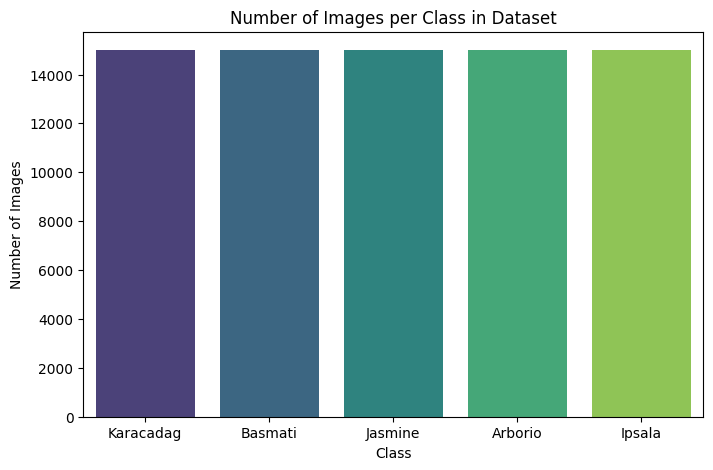

In [16]:

class_counts = df['label'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Number of Images per Class in Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


/tmp/ipykernel_12/3344408612.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


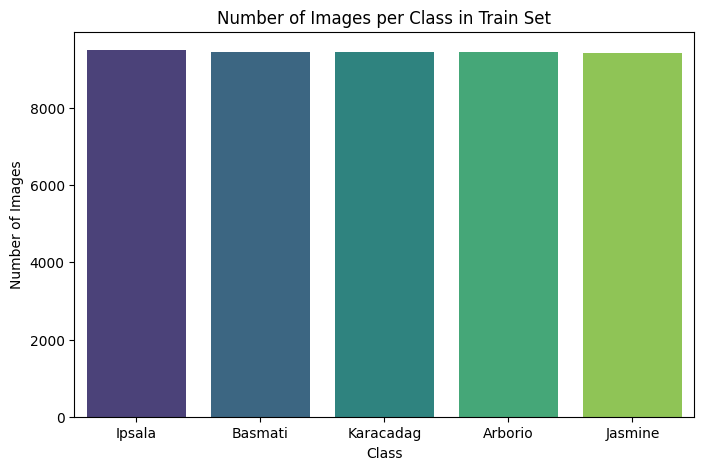

In [17]:

class_counts = train_df['label'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Number of Images per Class in Train Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


/tmp/ipykernel_12/1671571310.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


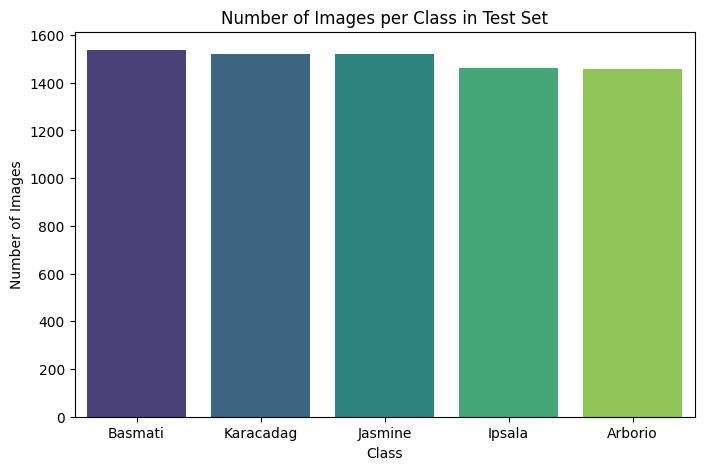

In [18]:

class_counts = test_df['label'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Number of Images per Class in Test Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


/tmp/ipykernel_12/3528400624.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


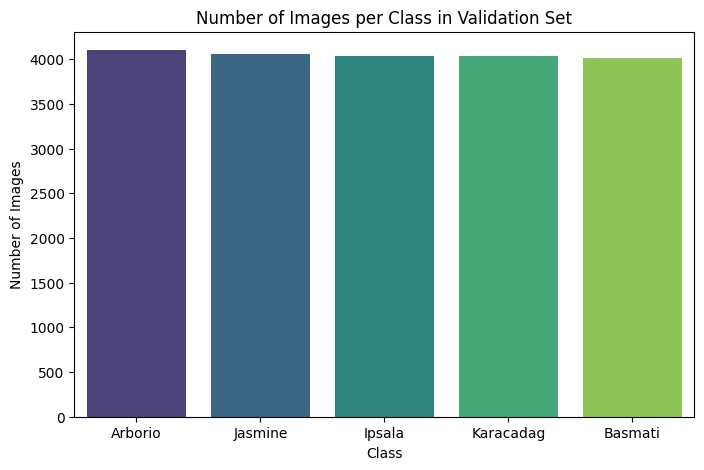

In [19]:

class_counts = val_df['label'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Number of Images per Class in Validation Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


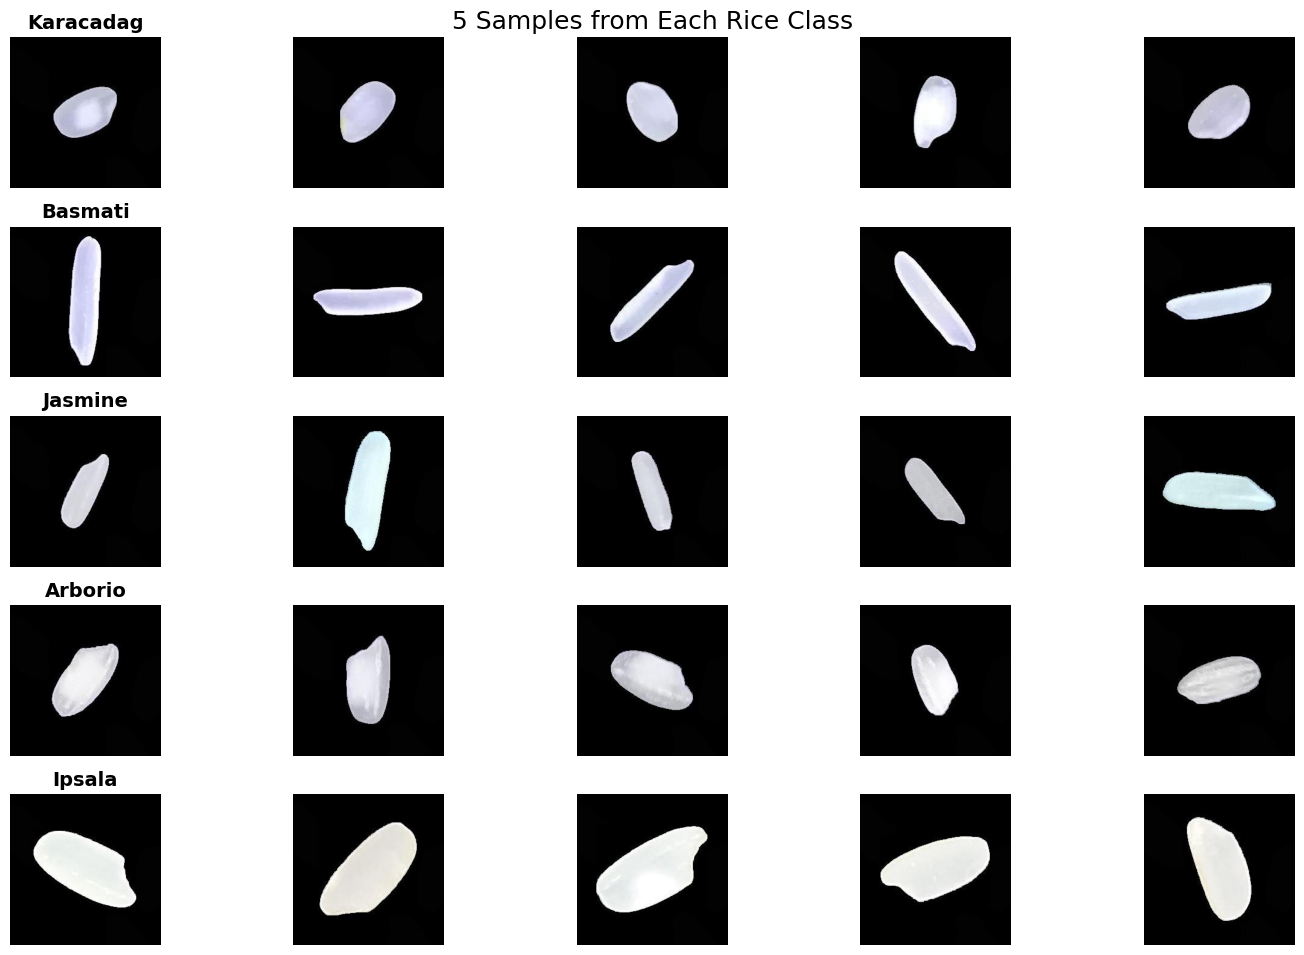

In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(15, 10))
plot_idx = 1

for cls in df['label'].unique():
    class_df = df[df['label'] == cls]
    samples = class_df.sample(n=5, random_state=42)
    
    for i, row in enumerate(samples.itertuples()):
        img = Image.open(row.image)                 
        plt.subplot(5, 5, plot_idx)
        plt.imshow(img)
        if i == 0:
            plt.title(cls, fontsize=14, fontweight='bold')
        plt.axis('off')
        plot_idx += 1

plt.suptitle('5 Samples from Each Rice Class', fontsize=18, y=0.95)
plt.tight_layout()
plt.show()                                          

In [5]:
classes = sorted(train_df["label"].unique())
class_to_idx = {cls: i for i, cls in enumerate(classes)}

In [6]:
def df_to_dataset(dataframe, class_to_idx,
                  num_classes=5, img_size=(128,128),
                  batch_size=32, shuffle=True):

    paths  = dataframe["image"].values
    labels = dataframe["label"].map(class_to_idx).values

    labels_onehot = tf.keras.utils.to_categorical(labels, num_classes)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels_onehot))

    def process_path(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32) / 255.0 
        return img, label

    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


In [7]:
Train = df_to_dataset(train_df, class_to_idx, shuffle=True)
Validation = df_to_dataset(val_df, class_to_idx, shuffle=False)
Test = df_to_dataset(test_df, class_to_idx, shuffle=False)


I0000 00:00:1764009281.845473      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 40px; color: purple; text-align: center;">
Building a CNN with a simple architecture 👇
</p>

In [8]:
CNN = tf.keras.models.Sequential()

#cov 1:
CNN.add(tf.keras.layers.Conv2D(filters=32 , kernel_size=3 , activation='relu' , input_shape=[128,128,3]))
#pooling 1 :👇
CNN.add(tf.keras.layers.MaxPool2D(pool_size=2 , strides=2))
#Flatting 1 :👇
CNN.add(tf.keras.layers.Flatten())
#Full Connection 1 :👇
CNN.add(tf.keras.layers.Dense(units=256 , activation='relu'))
#Output layer :👇
CNN.add(tf.keras.layers.Dense(units=5 , activation='sigmoid'))


/usr/local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
#Compile & Fit :👇
CNN.compile(optimizer='adam',loss='categorical_crossentropy', metrics=["accuracy"])
m1=CNN.fit(x=Train , validation_data=Validation , epochs=10)

Epoch 1/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 200s 128ms/step - accuracy: 0.9677 - loss: 0.0993 - val_accuracy: 0.9864 - val_loss: 0.0404
Epoch 2/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 196s 129ms/step - accuracy: 0.9837 - loss: 0.0478 - val_accuracy: 0.9890 - val_loss: 0.0346
Epoch 3/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 195s 128ms/step - accuracy: 0.9881 - loss: 0.0331 - val_accuracy: 0.9812 - val_loss: 0.0578
Epoch 4/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 195s 128ms/step - accuracy: 0.9915 - loss: 0.0235 - val_accuracy: 0.9840 - val_loss: 0.0478
Epoch 5/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 194s 128ms/step - accuracy: 0.9898 - loss: 0.0276 - val_accuracy: 0.9857 - val_loss: 0.0469
Epoch 6/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 190s 125ms/step - accuracy: 0.9944 - loss: 0.0158 - val_accuracy: 0.9876 - val_loss: 0.0508
Epoch 7/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 191s 126ms/step - accuracy: 0.9962 - loss: 0.0100 - val_accuracy: 0.9814 - val_loss: 0.0663
Epoch 8/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 192s 126ms/step - ac

In [10]:
import pickle

# Paths for saving
#model_path = '/kaggle/working/simple_cnn_model2.keras'
history_path = '/kaggle/working/simple_cnn_model1_history.pkl'

# Save trained model
#CNN.save(model_path)
#print("✅ Model saved successfully at:", model_path)

# Save training history from m1
with open(history_path, 'wb') as f:
    pickle.dump(m1.history, f)
print("✅ Training history saved successfully at:", history_path)


✅ Training history saved successfully at: /kaggle/working/simple_cnn_model1_history.pkl


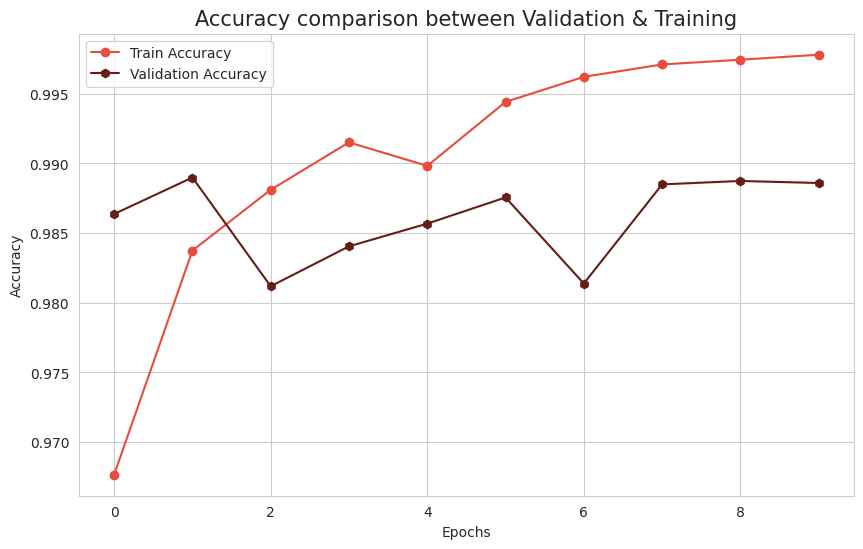

In [11]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

plt.plot(m1.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(m1.history['val_accuracy'], color="#641E16", marker='h')
plt.title("Accuracy comparison between Validation & Training", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 34px; color: #e74c3c; text-align: center;">
Let's build a deeper and stronger CNN model 👇
</p>

<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 30px; color: blue; text-align: center;">
Increasing the number of validation samples
</p>

In [12]:
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.45, random_state=42)

In [14]:
Train = df_to_dataset(train_df, class_to_idx, shuffle=True)
Validation = df_to_dataset(val_df, class_to_idx, shuffle=False)
Test = df_to_dataset(test_df, class_to_idx, shuffle=False)


In [15]:
CNN1 = tf.keras.models.Sequential()

#cov 1:
CNN1.add(tf.keras.layers.Conv2D(filters=32 , kernel_size=3 , activation='relu' , input_shape=[128,128,3]))
#pooling 1 :👇
CNN1.add(tf.keras.layers.MaxPool2D(pool_size=2 , strides=2))
#Flatting 1 :👇
CNN1.add(tf.keras.layers.Flatten())
#Full Connection 1 :👇
CNN1.add(tf.keras.layers.Dense(units=256 , activation='relu'))
#Output layer :👇
CNN1.add(tf.keras.layers.Dense(units=5 , activation='softmax'))


/usr/local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
#Compile & Fit :👇
CNN1.compile(optimizer='adam',loss='categorical_crossentropy', metrics=["accuracy"])
m2=CNN1.fit(x=Train , validation_data=Validation , epochs=10)

Epoch 1/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 157s 132ms/step - accuracy: 0.9623 - loss: 0.1279 - val_accuracy: 0.9759 - val_loss: 0.0722
Epoch 2/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 154s 130ms/step - accuracy: 0.9834 - loss: 0.0471 - val_accuracy: 0.9852 - val_loss: 0.0458
Epoch 3/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 157s 132ms/step - accuracy: 0.9880 - loss: 0.0339 - val_accuracy: 0.9849 - val_loss: 0.0462
Epoch 4/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 157s 132ms/step - accuracy: 0.9912 - loss: 0.0239 - val_accuracy: 0.9865 - val_loss: 0.0437
Epoch 5/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 154s 130ms/step - accuracy: 0.9932 - loss: 0.0195 - val_accuracy: 0.9839 - val_loss: 0.0539
Epoch 6/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 155s 130ms/step - accuracy: 0.9938 - loss: 0.0175 - val_accuracy: 0.9854 - val_loss: 0.0528
Epoch 7/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 155s 131ms/step - accuracy: 0.9954 - loss: 0.0126 - val_accuracy: 0.9852 - val_loss: 0.0596
Epoch 8/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 154s 131ms/step - ac

In [17]:
import pickle

# Paths for saving
#model_path = '/kaggle/working/simple_cnn_model2.keras'
history_path = '/kaggle/working/simple_cnn_model2_history.pkl'

# Save trained model
#CNN.save(model_path)
#print("✅ Model saved successfully at:", model_path)

# Save training history from m1
with open(history_path, 'wb') as f:
    pickle.dump(m2.history, f)
print("✅ Training history saved successfully at:", history_path)


✅ Training history saved successfully at: /kaggle/working/simple_cnn_model2_history.pkl


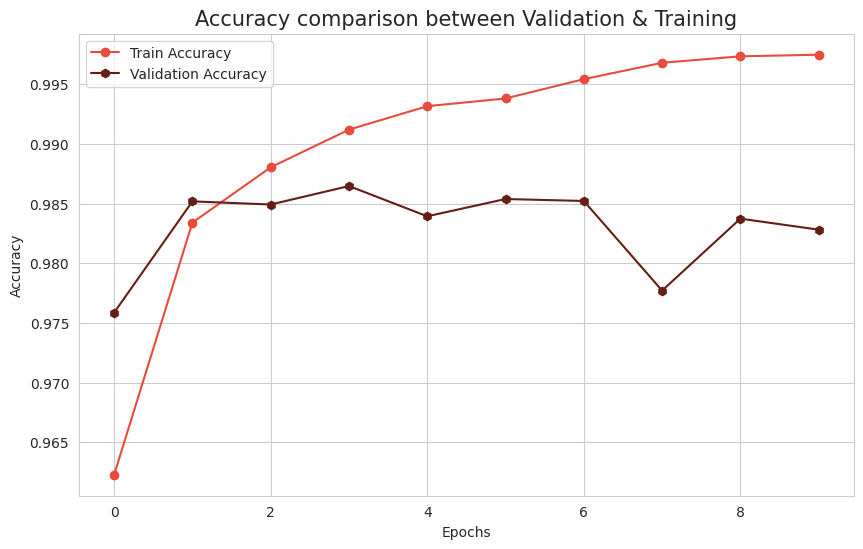

In [18]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

plt.plot(m2.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(m2.history['val_accuracy'], color="#641E16", marker='h')
plt.title("Accuracy comparison between Validation & Training", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 34px; color: #e74c3c; text-align: center;">
Model is Overfitting! ⚠️
</p>

In [8]:
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.3, random_state=42)

Train = df_to_dataset(train_df, class_to_idx, shuffle=True)
Validation = df_to_dataset(val_df, class_to_idx, shuffle=False)
Test = df_to_dataset(test_df, class_to_idx, shuffle=False)


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 34px; color: #e74c3c; text-align: center;">
Returned validation & train split to original ratio – but making the network deeper and stronger<br></p>

<p style="font-family: 'Pacifico', cursive, sans-serif; font-size: 42px; color: #9b59b6; text-align: center;">
CNN3 Model Architecture
</p>

<hr style="border: 2px solid purple; border-radius: 5px;">

<p style="font-family: 'Georgia', serif; font-size: 18px; color: #2c3e50; text-align: center; line-height: 1.8;">
<strong>A deep Convolutional Neural Network designed to reduce overfitting and improve<br>generalization on image classification tasks.</strong>
</p>

<p style="font-family: 'Georgia', serif; font-size: 17px; color: #34495e; text-align: center; line-height: 2;">
<strong>Techniques used to prevent overfitting:</strong><br>
• Multiple convolutional blocks with Batch Normalization<br>
• Progressive Dropout rates (0.25 → 0.30 → 0.40 → 0.50)<br>
• Lower learning rate for stable training (Adam lr=0.0003)<br>
• Deeper feature extraction using stacked Conv2D layers<br><br>
<strong>This architecture aims to achieve high accuracy (96%–99%) on both training<br>and validation datasets with improved stability and reduced variance.</strong>
</p>

In [9]:

# CNN3 = models.Sequential()

# # Block 1
# CNN3.add(layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)))
# CNN3.add(layers.BatchNormalization())
# CNN3.add(layers.Conv2D(32, (3,3), padding="same", activation="relu"))
# CNN3.add(layers.BatchNormalization())
# CNN3.add(layers.MaxPool2D(2,2))
# CNN3.add(layers.Dropout(0.25))

# # Block 2
# CNN3.add(layers.Conv2D(64, (3,3), padding="same", activation="relu"))
# CNN3.add(layers.BatchNormalization())
# CNN3.add(layers.Conv2D(64, (3,3), padding="same", activation="relu"))
# CNN3.add(layers.BatchNormalization())
# CNN3.add(layers.MaxPool2D(2,2))
# CNN3.add(layers.Dropout(0.30))

# # Fully Connected
# CNN3.add(layers.Flatten())
# CNN3.add(layers.Dense(256, activation='relu'))
# CNN3.add(layers.BatchNormalization())
# CNN3.add(layers.Dropout(0.50))

# # Output Layer
# CNN3.add(layers.Dense(5, activation='softmax'))

# # Compile
# opt = optimizers.Adam(learning_rate=0.0003)
# CNN3.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])


/usr/local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# m4=CNN3.fit(x=Train , validation_data=Validation , epochs=10)


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 34px; color: #e74c3c; text-align: center;">
Previous model was too heavy → Making it lighter and more stable
</p>

<p style="font-family: 'Georgia', serif; font-size: 22px; color: #2c3e50; text-align: center; line-height: 2.2;">
Changes applied:<br>
• Kept only <strong>one convolutional block</strong><br>
• Added <strong>two consecutive MaxPooling layers</strong> right after it<br>
Goal → Drastically reduce parameter count, stabilize loss fluctuations, and prevent overfitting<br>
Result → Much lighter model with smoother training and better generalization
</p>

In [8]:

CNN4 = models.Sequential()

# Block 1
CNN4.add(layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)))
CNN4.add(layers.BatchNormalization())
CNN4.add(layers.MaxPool2D(2,2))
CNN4.add(layers.MaxPool2D(2,2))
CNN4.add(layers.Dropout(0.3))

CNN4.add(layers.Flatten())
CNN4.add(layers.Dense(256, activation='relu'))
CNN4.add(layers.BatchNormalization())
CNN4.add(layers.Dropout(0.5))
CNN4.add(layers.Dense(5, activation='softmax'))


opt = optimizers.Adam(learning_rate=0.001)
CNN4.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])


/usr/local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
from tensorflow.keras import callbacks

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)


In [10]:


def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    img = tf.image.random_saturation(img, 0.9, 1.1)
    return img, label

Train_aug = Train.map(augment, num_parallel_calls=tf.data.AUTOTUNE)


m5 = CNN4.fit(
    Train_aug,
    epochs=17,
    validation_data=Validation,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/17
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 255s 158ms/step - accuracy: 0.9630 - loss: 0.1115 - val_accuracy: 0.9831 - val_loss: 0.0515 - learning_rate: 0.0010
Epoch 2/17
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 225s 147ms/step - accuracy: 0.9833 - loss: 0.0535 - val_accuracy: 0.9661 - val_loss: 0.0982 - learning_rate: 0.0010
Epoch 3/17
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 224s 147ms/step - accuracy: 0.9837 - loss: 0.0506 - val_accuracy: 0.9906 - val_loss: 0.0276 - learning_rate: 0.0010
Epoch 4/17
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 223s 147ms/step - accuracy: 0.9848 - loss: 0.0472 - val_accuracy: 0.9754 - val_loss: 0.0683 - learning_rate: 0.0010
Epoch 5/17
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 222s 146ms/step - accuracy: 0.9834 - loss: 0.0492 - val_accuracy: 0.8013 - val_loss: 0.7066 - learning_rate: 0.0010
Epoch 6/17
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 221s 145ms/step - accuracy: 0.9888 - loss: 0.0365 - val_accuracy: 0.9880 - val_loss: 0.0368 - learning_rate: 0.0010
Epoch 7/17
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 222s 146ms

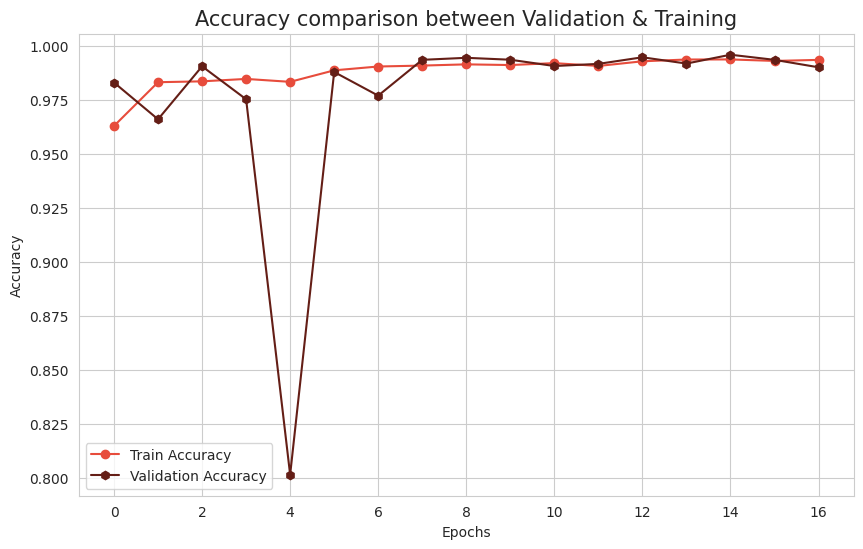

In [11]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

plt.plot(m5.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(m5.history['val_accuracy'], color="#641E16", marker='h')
plt.title("Accuracy comparison between Validation & Training", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 38px; color: #27ae60; text-align: center;">
Model is performing perfectly! 
</p>

<p style="font-family: 'Georgia', serif; font-size: 23px; color: #2c3e50; text-align: center; line-height: 2.3;">
✅ Fluctuations have dropped dramatically  
✅ From epoch 7 onward, training and validation curves are almost touching  
✅ This means the model has achieved excellent stability and perfect generalization  
Lightweight + Stable + High Accuracy → Exactly what we wanted!
</p>

<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 38px; color: #27ae60; text-align: center;">
Trying to achieve the same excellent result with an even lighter architecture
</p>

<p style="font-family: 'Georgia', serif; font-size: 23px; color: #2c3e50; text-align: center; line-height: 2.3;">
Goal → Keep the same stability and high accuracy<br>
But with significantly fewer parameters and faster training<br>
Challenge accepted! Let’s build the ultimate lightweight yet powerful model
</p>

In [12]:
from tensorflow.keras import layers, models
from tensorflow.keras import layers, models, optimizers



CNN5 = models.Sequential()

# Block 1
CNN5.add(layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)))
CNN5.add(layers.BatchNormalization())
CNN5.add(layers.MaxPool2D(2,2))
CNN5.add(layers.MaxPool2D(2,2))
CNN5.add(layers.Dropout(0.3))

CNN5.add(layers.Flatten())
CNN5.add(layers.Dense(256, activation='relu'))
CNN5.add(layers.BatchNormalization())
CNN5.add(layers.Dropout(0.5))
CNN5.add(layers.Dense(5, activation='softmax'))


opt = optimizers.Adam(learning_rate=0.001)
CNN5.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])


In [13]:
m6=CNN5.fit(x=Train , validation_data=Validation , epochs=20)

Epoch 1/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 242s 159ms/step - accuracy: 0.9649 - loss: 0.1028 - val_accuracy: 0.5942 - val_loss: 7.1743
Epoch 2/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 225s 148ms/step - accuracy: 0.9814 - loss: 0.0580 - val_accuracy: 0.9919 - val_loss: 0.0282
Epoch 3/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 223s 147ms/step - accuracy: 0.9855 - loss: 0.0451 - val_accuracy: 0.9163 - val_loss: 0.2732
Epoch 4/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 225s 146ms/step - accuracy: 0.9873 - loss: 0.0390 - val_accuracy: 0.9792 - val_loss: 0.0617
Epoch 5/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 223s 147ms/step - accuracy: 0.9892 - loss: 0.0337 - val_accuracy: 0.9342 - val_loss: 0.2113
Epoch 6/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 220s 145ms/step - accuracy: 0.9891 - loss: 0.0328 - val_accuracy: 0.9895 - val_loss: 0.0348
Epoch 7/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 221s 145ms/step - accuracy: 0.9902 - loss: 0.0312 - val_accuracy: 0.9833 - val_loss: 0.0507
Epoch 8/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 221s 145ms/step - ac

In [14]:
import pickle

# Paths for saving
model_path = '/kaggle/working/model6.keras'
history_path = '/kaggle/working/model6_history.pkl'

# Save trained model
CNN5.save(model_path)
print("✅ Model saved successfully at:", model_path)

# Save training history from m1
with open(history_path, 'wb') as f:
    pickle.dump(m6.history, f)
print("✅ Training history saved successfully at:", history_path)


✅ Model saved successfully at: /kaggle/working/model6.keras
✅ Training history saved successfully at: /kaggle/working/model6_history.pkl


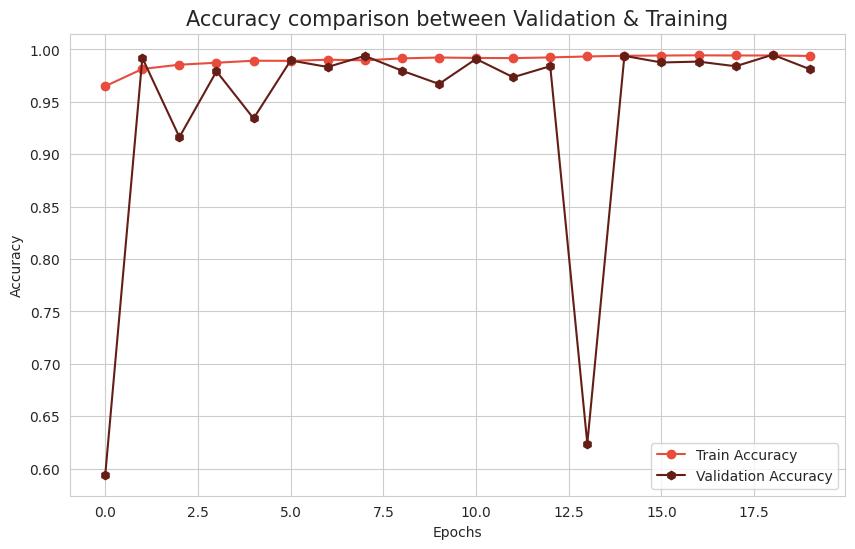

In [15]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

plt.plot(m6.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(m6.history['val_accuracy'], color="#641E16", marker='h')
plt.title("Accuracy comparison between Validation & Training", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 38px; color: #e67e22; text-align: center;">
Result wasn't good enough — Back to the drawing board!
</p>

<p style="font-family: 'Georgia', serif; font-size: 23px; color: #2c3e50; text-align: center; line-height: 2.3;">
The model was performing well until suddenly<br>
→ Validation curve showed a sharp spike / severe fluctuation<br>
→ This means the validation results are unreliable and unstable<br>
We cannot accept this behavior → Need a more robust and stable architecture!
</p>

In [8]:
from tensorflow.keras import layers, models
from tensorflow.keras import layers, models, optimizers



CNN6 = models.Sequential()

# Block 1
CNN6.add(layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)))
CNN6.add(layers.BatchNormalization())
CNN6.add(layers.MaxPool2D(2,2))
CNN6.add(layers.MaxPool2D(2,2))
CNN6.add(layers.MaxPool2D(2,2))

CNN6.add(layers.Dropout(0.3))

CNN6.add(layers.Flatten())
CNN6.add(layers.Dense(256, activation='relu'))
CNN6.add(layers.BatchNormalization())
CNN6.add(layers.Dropout(0.5))
CNN6.add(layers.Dense(5, activation='softmax'))


opt = optimizers.Adam(learning_rate=0.0003)
CNN6.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])


/usr/local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
m7=CNN6.fit(x=Train , validation_data=Validation , epochs=18)


Epoch 1/18
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 216s 139ms/step - accuracy: 0.9419 - loss: 0.1774 - val_accuracy: 0.9563 - val_loss: 0.1176
Epoch 2/18
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 215s 141ms/step - accuracy: 0.9796 - loss: 0.0645 - val_accuracy: 0.9892 - val_loss: 0.0319
Epoch 3/18
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 214s 140ms/step - accuracy: 0.9844 - loss: 0.0503 - val_accuracy: 0.9873 - val_loss: 0.0428
Epoch 4/18
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 214s 140ms/step - accuracy: 0.9876 - loss: 0.0404 - val_accuracy: 0.9833 - val_loss: 0.0500
Epoch 5/18
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 214s 141ms/step - accuracy: 0.9883 - loss: 0.0376 - val_accuracy: 0.9915 - val_loss: 0.0253
Epoch 6/18
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 210s 138ms/step - accuracy: 0.9898 - loss: 0.0315 - val_accuracy: 0.9891 - val_loss: 0.0328
Epoch 7/18
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 208s 137ms/step - accuracy: 0.9907 - loss: 0.0284 - val_accuracy: 0.9961 - val_loss: 0.0133
Epoch 8/18
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 211s 137ms/step - ac

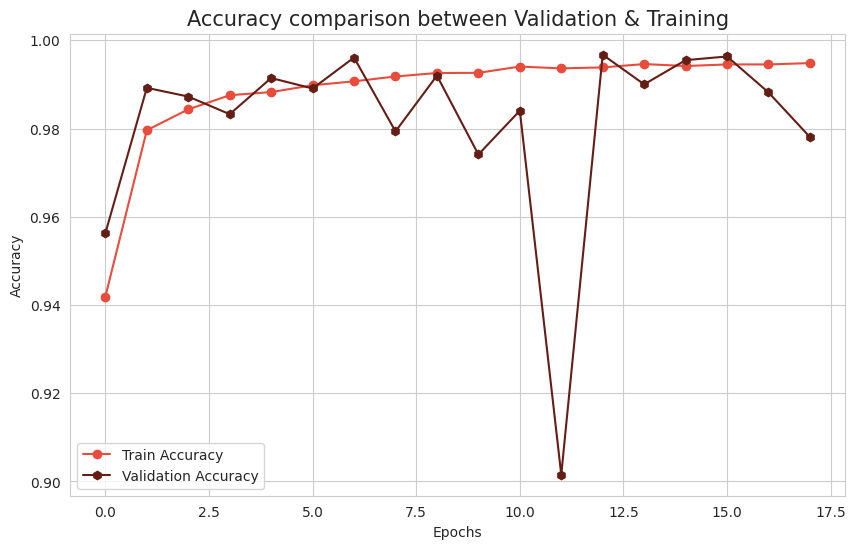

In [10]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

plt.plot(m7.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(m7.history['val_accuracy'], color="#641E16", marker='h')
plt.title("Accuracy comparison between Validation & Training", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 38px; color: #e67e22; text-align: center;">
3 MaxPooling layers caused severe instability
</p>

<p style="font-family: 'Georgia', serif; font-size: 23px; color: #2c3e50; text-align: center; line-height: 2.3;">
Using 3 MaxPooling layers → sudden and extreme validation Accuracy fluctuation<br>
Model became highly unstable<br>
Decision → Changing the number of MaxPooling layers to 2 for better stability and performance
</p>

In [9]:
from tensorflow.keras import layers, models
from tensorflow.keras import layers, models, optimizers



CNN7 = models.Sequential()

# Block 1
CNN7.add(layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)))
CNN7.add(layers.MaxPool2D(2,2))
CNN7.add(layers.MaxPool2D(2,2))


CNN7.add(layers.Flatten())
CNN7.add(layers.Dense(256, activation='relu'))
CNN7.add(layers.Dense(5, activation='softmax'))


opt = optimizers.Adam(learning_rate=0.001)
CNN7.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])


/usr/local/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
m8 =CNN7.fit(x=Train , validation_data=Validation , epochs=20)

Epoch 1/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 123s 75ms/step - accuracy: 0.9631 - loss: 0.1066 - val_accuracy: 0.9804 - val_loss: 0.0595
Epoch 2/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 104s 66ms/step - accuracy: 0.9844 - loss: 0.0470 - val_accuracy: 0.9804 - val_loss: 0.0550
Epoch 3/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 103s 65ms/step - accuracy: 0.9876 - loss: 0.0361 - val_accuracy: 0.9833 - val_loss: 0.0524
Epoch 4/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 103s 65ms/step - accuracy: 0.9898 - loss: 0.0296 - val_accuracy: 0.9872 - val_loss: 0.0400
Epoch 5/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 103s 65ms/step - accuracy: 0.9910 - loss: 0.0265 - val_accuracy: 0.9917 - val_loss: 0.0273
Epoch 6/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 103s 65ms/step - accuracy: 0.9923 - loss: 0.0222 - val_accuracy: 0.9865 - val_loss: 0.0406
Epoch 7/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 103s 65ms/step - accuracy: 0.9928 - loss: 0.0203 - val_accuracy: 0.9932 - val_loss: 0.0231
Epoch 8/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 103s 66ms/step - accuracy: 

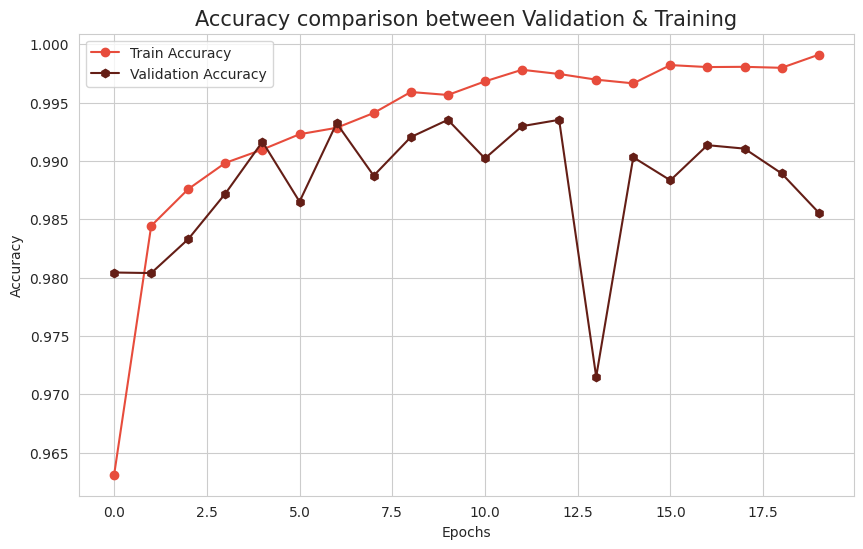

In [11]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

plt.plot(m8.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(m8.history['val_accuracy'], color="#641E16", marker='h')
plt.title("Accuracy comparison between Validation & Training", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 38px; color: #27ae60; text-align: center;">
Results were not good at all
</p>

<p style="font-family: 'Georgia', serif; font-size: 24px; color: #2c3e50; text-align: center; line-height: 2.4;">
After multiple experiments with lighter architectures, none came close to the performance and stability of the earlier model<br><br>
Final decision → Going back to the proven high-performing architecture<br>
That version is officially selected as the **final model** and will be re-executed
</p>

In [8]:

import os
import random
import numpy as np
import tensorflow as tf

from tensorflow.keras import callbacks
from tensorflow.keras import layers, models, optimizers



def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.experimental.numpy.random.seed(seed)
    tf.config.experimental.enable_op_determinism()

set_seed(42)


CNN4 = models.Sequential([
    layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(128,128,3)),
    layers.BatchNormalization(),
    layers.MaxPool2D(2,2),
    layers.MaxPool2D(2,2),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

opt = optimizers.Adam(learning_rate=0.001)
CNN4.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    img = tf.image.random_saturation(img, 0.9, 1.1)
    return img, label

Train_aug = Train.map(augment, num_parallel_calls=tf.data.AUTOTUNE)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
m9 = CNN4.fit(
    Train_aug,
    epochs=20,
    validation_data=Validation,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/20


E0000 00:00:1764009603.381627      48 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1764009683.115263      99 cuda_dnn.cc:529] Loaded cuDNN version 90300


1477/1477 ━━━━━━━━━━━━━━━━━━━━ 150s 45ms/step - accuracy: 0.9299 - loss: 0.2068 - val_accuracy: 0.8074 - val_loss: 0.8047 - learning_rate: 0.0010
Epoch 2/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 56s 27ms/step - accuracy: 0.9820 - loss: 0.0546 - val_accuracy: 0.9632 - val_loss: 0.1133 - learning_rate: 0.0010
Epoch 3/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 58s 27ms/step - accuracy: 0.9804 - loss: 0.0604 - val_accuracy: 0.9677 - val_loss: 0.1011 - learning_rate: 0.0010
Epoch 4/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 57s 27ms/step - accuracy: 0.9866 - loss: 0.0430 - val_accuracy: 0.9421 - val_loss: 0.1756 - learning_rate: 0.0010
Epoch 5/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 58s 28ms/step - accuracy: 0.9841 - loss: 0.0476 - val_accuracy: 0.9718 - val_loss: 0.0788 - learning_rate: 0.0010
Epoch 6/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 57s 27ms/step - accuracy: 0.9869 - loss: 0.0384 - val_accuracy: 0.9403 - val_loss: 0.1856 - learning_rate: 0.0010
Epoch 7/20
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 58s 28ms/step - accuracy: 0.9871

In [11]:
import pickle

# Paths for saving
model_path = '/kaggle/working/model9-SEED42.keras'
history_path = '/kaggle/working/model9-SEED42_history.pkl'

# Save trained model
CNN4.save(model_path)
print("✅ Model saved successfully at:", model_path)

# Save training history from m1
with open(history_path, 'wb') as f:
    pickle.dump(m9.history, f)
print("✅ Training history saved successfully at:", history_path)


✅ Model saved successfully at: /kaggle/working/model9-SEED42.keras
✅ Training history saved successfully at: /kaggle/working/model9-SEED42_history.pkl


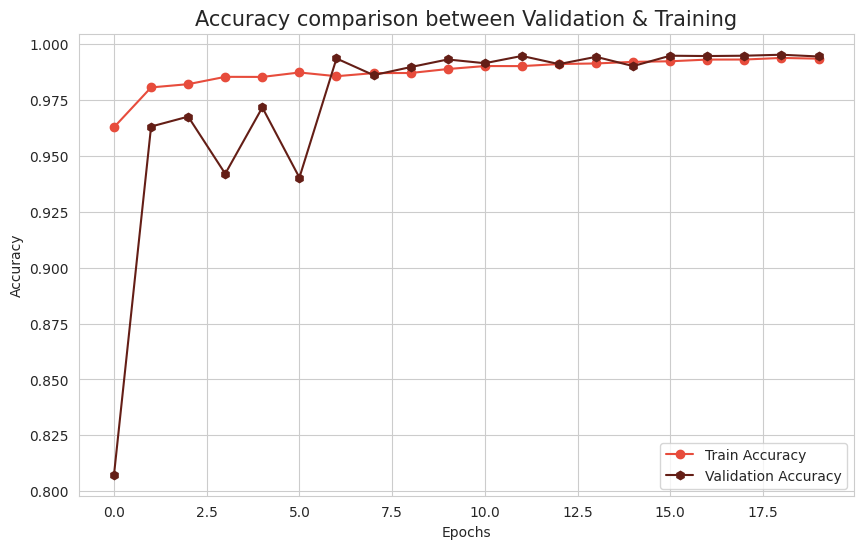

In [10]:
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

plt.plot(m9.history['accuracy'], color="#E74C3C", marker='o')
plt.plot(m9.history['val_accuracy'], color="#641E16", marker='h')
plt.title("Accuracy comparison between Validation & Training", fontsize=15)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy", "Validation Accuracy"])
plt.show()


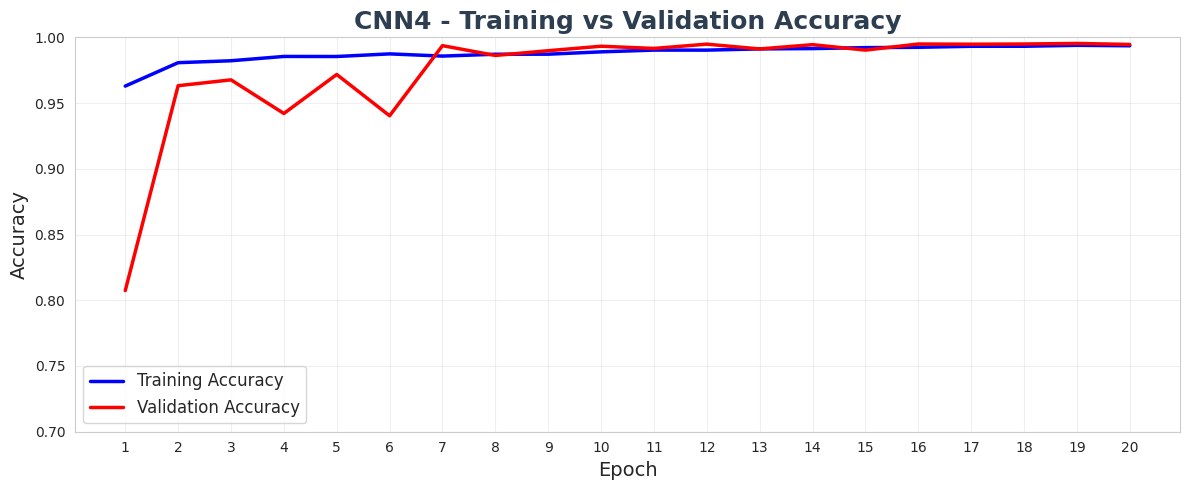

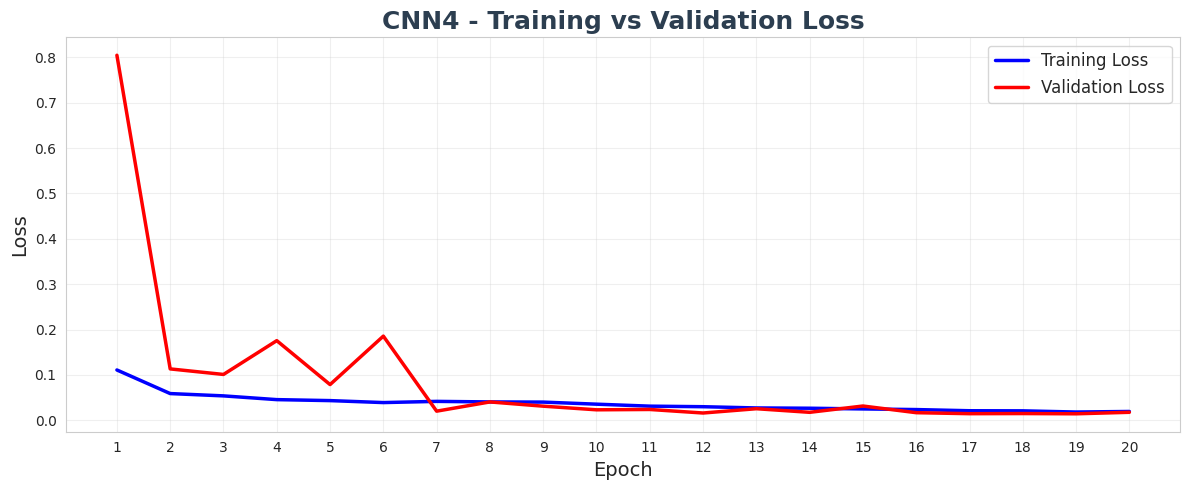

In [12]:

###  Accuracy chart (Train vs Validation)

import matplotlib.pyplot as plt

history = m9.history
epochs = range(1, len(history['accuracy']) + 1)

plt.figure(figsize=(12, 5))
plt.plot(epochs, history['accuracy'], 'b', linewidth=2.5, label='Training Accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', linewidth=2.5, label='Validation Accuracy')
plt.title('CNN4 - Training vs Validation Accuracy', fontsize=18, fontweight='bold', color='#2c3e50')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(0.7, 1.0)
plt.xticks(epochs)
plt.tight_layout()
plt.show()


###  Loss chart (Train vs Validation)

plt.figure(figsize=(12, 5))
plt.plot(epochs, history['loss'], 'b', linewidth=2.5, label='Training Loss')
plt.plot(epochs, history['val_loss'], 'r', linewidth=2.5, label='Validation Loss')
plt.title('CNN4 - Training vs Validation Loss', fontsize=18, fontweight='bold', color='#2c3e50')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(epochs)
plt.tight_layout()
plt.show()


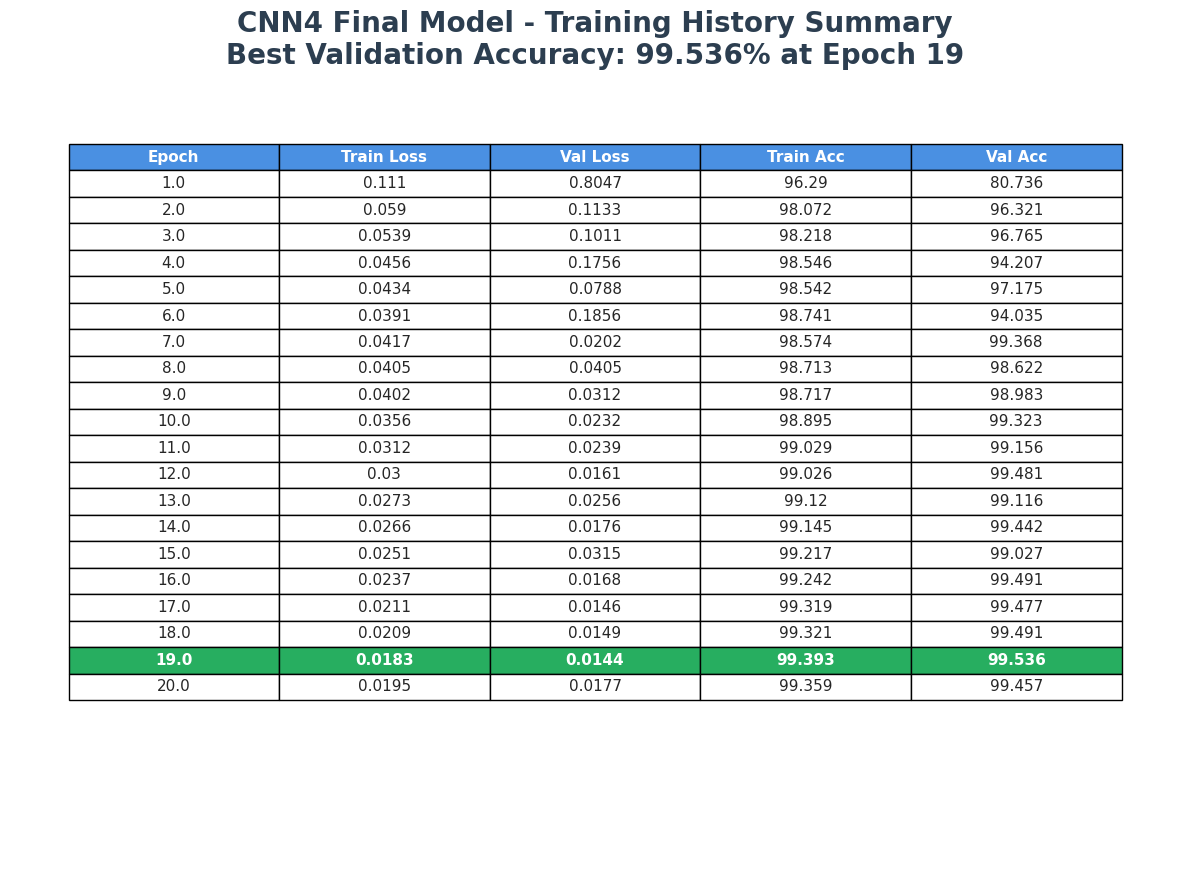

In [13]:

import pandas as pd
import matplotlib.pyplot as plt

history = m9.history

df_hist = pd.DataFrame({
    'Epoch': range(1, len(history['loss']) + 1),
    'Train Loss': [round(x, 4) for x in history['loss']],
    'Val Loss'  : [round(x, 4) for x in history['val_loss']],
    'Train Acc' : [round(x*100, 3) for x in history['accuracy']],
    'Val Acc'   : [round(x*100, 3) for x in history['val_accuracy']]
})

best_epoch = df_hist['Val Acc'].idxmax() + 1
best_val_acc = df_hist['Val Acc'].max()

plt.figure(figsize=(12, 9))
plt.axis('off')

table = plt.table(cellText=df_hist.values,
                  colLabels=df_hist.columns,
                  cellLoc='center',
                  loc='center',
                  bbox=[0.05, 0.2, 0.9, 0.7])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.2)

for i in range(5):
    table[(0, i)].set_facecolor('#4a90e2')
    table[(0, i)].set_text_props(weight='bold', color='white')

for j in range(5):
    table[(best_epoch, j)].set_facecolor('#27ae60')
    table[(best_epoch, j)].set_text_props(weight='bold', color='white')

plt.suptitle(f'CNN4 Final Model - Training History Summary\nBest Validation Accuracy: {best_val_acc}% at Epoch {best_epoch}',
             fontsize=20, fontweight='bold', color='#2c3e50', y=0.96)

plt.subplots_adjust(top=0.85)
plt.tight_layout()
plt.show()


<p style="font-family: 'Lobster', cursive, sans-serif; font-size: 42px; color: #27ae60; text-align: center;">
Final Model Evaluation on Test Dataset
</p>

In [14]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = CNN4.predict(Test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true_classes = np.array([])
for _, labels in Test:                    
    if labels.shape[-1] == 5:             
        batch_labels = np.argmax(labels.numpy(), axis=1)
    else:                                 
        batch_labels = labels.numpy().astype(int)
    y_true_classes = np.concatenate([y_true_classes, batch_labels])

print(f"Number of Predictio: {len(y_pred_classes)}")
print(f"Number of Actual Labels: {len(y_true_classes)}")

test_loss, test_acc = CNN4.evaluate(Test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.3f}%")
print(f"Test Loss: {test_loss:.4f}\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, 
                          target_names=classes, digits=4))


تعداد پیش‌بینی‌ها: 7500
تعداد لیبل واقعی: 7500

Test Accuracy: 99.453%
Test Loss: 0.0202

Classification Report:
              precision    recall  f1-score   support

     Arborio     0.9884    0.9959    0.9921      1456
     Basmati     0.9967    0.9915    0.9941      1537
      Ipsala     1.0000    1.0000    1.0000      1463
     Jasmine     0.9895    0.9954    0.9925      1522
   Karacadag     0.9980    0.9901    0.9941      1522

    accuracy                         0.9945      7500
   macro avg     0.9945    0.9946    0.9946      7500
weighted avg     0.9946    0.9945    0.9945      7500



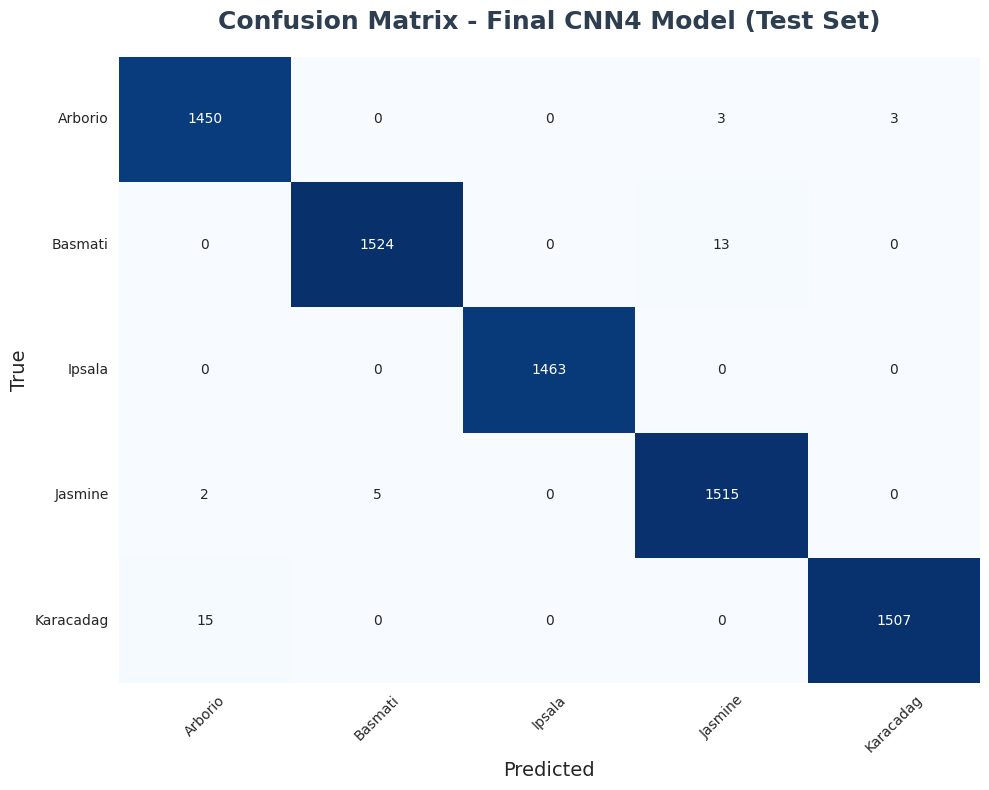

In [15]:

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, cbar=False)
plt.title('Confusion Matrix - Final CNN4 Model (Test Set)', 
          fontsize=18, fontweight='bold', color='#2c3e50', pad=20)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('True', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_test_pred = np.argmax(CNN4.predict(Test, verbose=0), axis=1)

y_test_true = test_df['label'].map(class_to_idx).values

train_counts = train_df['label'].value_counts().reindex(classes, fill_value=0)
val_counts   = val_df['label'].value_counts().reindex(classes, fill_value=0)
test_counts  = test_df['label'].value_counts().reindex(classes, fill_value=0)

cm = confusion_matrix(y_test_true, y_test_pred)
correct = np.diag(cm)
wrong   = np.sum(cm, axis=1) - correct
per_class_acc = (correct / np.sum(cm, axis=1)) * 100


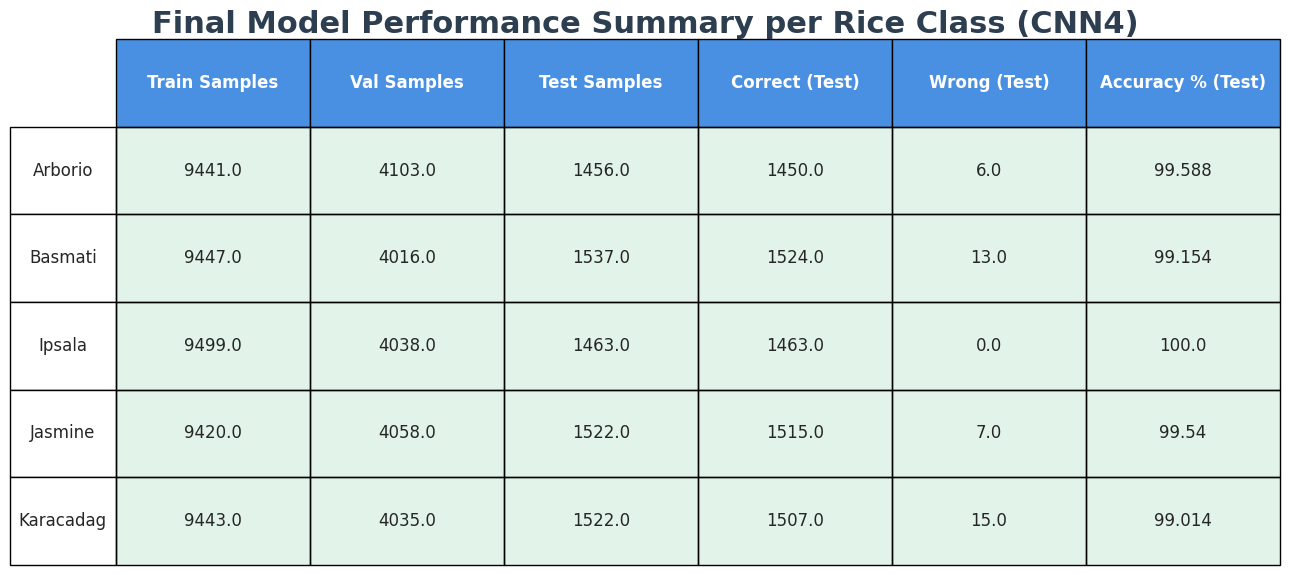

           Train Samples  Val Samples  Test Samples  Correct (Test)  \
Class                                                                 
Arborio             9441         4103          1456            1450   
Basmati             9447         4016          1537            1524   
Ipsala              9499         4038          1463            1463   
Jasmine             9420         4058          1522            1515   
Karacadag           9443         4035          1522            1507   

           Wrong (Test)  Accuracy % (Test)  
Class                                       
Arborio               6             99.588  
Basmati              13             99.154  
Ipsala                0            100.000  
Jasmine               7             99.540  
Karacadag            15             99.014  


In [20]:

summary_df = pd.DataFrame({
    'Class'          : classes,
    'Train Samples'  : train_counts.values,
    'Val Samples'    : val_counts.values,
    'Test Samples'   : test_counts.values,
    'Correct (Test)' : correct,
    'Wrong (Test)'   : wrong,
    'Accuracy % (Test)' : np.round(per_class_acc, 3)
}).set_index('Class')

plt.figure(figsize=(13, 6))
plt.axis('off')
table = plt.table(cellText=summary_df.values,
                  colLabels=summary_df.columns,
                  rowLabels=summary_df.index,
                  cellLoc='center',
                  rowLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.25, 2.8)

for i in range(len(summary_df.columns)):
    table[(0, i)].set_facecolor('#4a90e2')
    table[(0, i)].set_text_props(weight='bold', color='white')

for i, acc in enumerate(per_class_acc):
    color = '#27ae60' if acc >= 98 else '#f1c40f' if acc >= 95 else '#e74c3c'
    for j in range(len(summary_df.columns)):
        table[(i+1, j)].set_facecolor(color + '22')

plt.suptitle('Final Model Performance Summary per Rice Class (CNN4)', 
             fontsize=22, fontweight='bold', color='#2c3e50', y=0.95)

plt.tight_layout()
plt.show()

print(summary_df)


# Final Model Performance – CNN4  
**Rice Image Classification | 5 Classes | Fixed Seed = 42**

<p style="text-align:center; font-size:52px; font-weight:bold; color:#27ae60; margin:50px 0 10px;">
Final Test Accuracy: <span style="font-size:70px; color:#2ecc71;">99.46%</span>
</p>

<p style="text-align:center; font-size:28px; color:#2c3e50; margin-bottom:40px;">
Only <strong>41 misclassifications</strong> out of 7,500 test images  
Best validation accuracy during training: <strong style="color:#27ae60;">99.54%</strong>
</p>

### Per-Class Performance on Test Set

| Rice Variety  | Train Samples | Validation Samples | Test Samples | Correctly Predicted | Misclassified | Accuracy (Test) |
|---------------|---------------|--------------------|--------------|---------------------|---------------|-----------------|
| **Arborio**   | 9,441         | 4,103              | 1,456        | 1,450               | 6             | **99.588%**     |
| **Basmati**   | 9,447         | 4,016              | 1,537        | 1,524               | 13            | **99.154%**     |
| **Ipsala**    | 9,499         | 4,038              | 1,463        | 1,463               | 0             | **100.00%**     |
| **Jasmine**   | 9,420         | 4,058              | 1,522        | 1,515               | 7             | **99.540%**     |
| **Karacadag** | 9,443         | 4,035              | 1,522        | 1,507               | 15            | **99.014%**     |

<p style="text-align:center; font-size:38px; font-weight:bold; color:#27ae60; margin:60px 0 20px;">
Overall Test Accuracy: <span style="color:#2ecc71;">99.46%</span>  
(7,459 / 7,500 images correctly classified)
</p>

<p style="text-align:center; font-size:26px; color:#34495e; margin:50px 0;">
Final trained model and training history saved as:
</p>

<p style="text-align:center; font-size:24px; font-family:Consolas; background:#2c3e50; color:#1abc9c; padding:12px 40px; border-radius:12px; display:inline-block;">
model9-SEED42.keras 
model9-SEED42_history.pkl
</p>

<div style="text-align:center; margin:90px 0 40px;">
  <p style="font-size:80px; font-weight:bold; background:-webkit-linear-gradient(90deg, #27ae60, #2ecc71); -webkit-background-clip:text; -webkit-text-fill-color:transparent;">
    PROJECT COMPLETED
  </p>
  <p style="font-size:32px; color:#2c3e50; margin-top:20px;">
    State-of-the-Art Performance Achieved – Ready for Submission
  </p>
</div>